# 메인 퀘스트: 고객 행동 예측 및 고객 데이터 분석

## **1. 문제 정의 및 데이터 이해**

**목표 설정**

- 비즈니스 문제: 통신사 고객 이탈을 예측하여 선제적 유지 전략 수립
- 분석 목표: 이탈에 영향을 미치는 주요 요인 파악 및 이탈 예측 모델 구축
- 성공 지표: 모델 정확도, Precision/Recall, F1-score, 비즈니스 액션 가능성 등

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.inspection import permutation_importance, partial_dependence

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plotting Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


#### 데이터셋 구조 파악

- churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
- 데이터 크기, 변수 개수, 데이터 타입 확인
- 각 변수의 의미와 비즈니스 맥락 이해

In [3]:
df = pd.read_csv('data/churn-bigml-80.csv')

In [6]:
df.shape

(2666, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [8]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [10]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
df.nunique()

State                       51
Account length             205
Area code                    3
International plan           2
Voice mail plan              2
Number vmail messages       42
Total day minutes         1489
Total day calls            115
Total day charge          1489
Total eve minutes         1442
Total eve calls            120
Total eve charge          1301
Total night minutes       1444
Total night calls          118
Total night charge         885
Total intl minutes         158
Total intl calls            21
Total intl charge          158
Customer service calls      10
Churn                        2
dtype: int64

______
####    각 변수의 의미와 비즈니스 맥락 이해
1. 고객 기본 정보 (가입 및 계약 환경)
    - State: 고객이 거주하는 주 (지역별 이탈률 차이가 있는지 확인 가능)
    - Account length: 가입 기간.(단위: 보통 일 또는 월) !! 핵심 변수:
        평균 100, min 1, max 243, 중앙값 100: 평균치와 중앙값 일치.
    - Area code: 지역 번호
    - International plan: 국제 전화 요금제 가입 여부 (Yes/No)
    - Voice mail plan: 음성 메일 요금제 가입 여부 (Yes/No)
2. 서비스 이용 패턴 (시간대별 활동량)
    - 낮, 저녁, 밤 각 통화 시간(Minutes), 통화 횟수, 요금
    - 음성 메일 메세지 개수

3. 고객 관리 및 결과 변수
    - Customer service calls: 고객 센터에 전화한 횟수. !! 이탈 예측의 강력한 트리거
    - Churn: 이탈 여부 (True: 이탈, False: 유지). !! 분석의 타겟 변수(Label)
----

### 데이터 전처리
- 결측치 존재 여부 확인
- 결측치 처리 전략 수립: 삭제, 평균/중앙값 대체, 또는 별도 카테고리 생성
- 처리 방법에 대한 근거 수립

In [12]:
df.isnull().sum()   # 표면적인 결측치는 없는 것으로 확인됨

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [21]:
# 각 컬럼별로 어떤 값들이 들어있는지 고유값(unique) 확인
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()[:20]}") # 상위 20개만 출력

State: ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'WV' 'RI' 'IA' 'MT' 'ID' 'VT' 'VA'
 'TX' 'FL' 'CO' 'AZ' 'NE' 'WY']
International plan: ['No' 'Yes']
Voice mail plan: ['Yes' 'No']


In [18]:
print(" 'Unknown' 기호 개수:", (df == 'Unknown').sum().sum())
print(" '?' 기호 개수:", (df == '?').sum().sum())
print(" '-' 기호 개수:", (df == '-').sum().sum())

 'Unknown' 기호 개수: 0
 '?' 기호 개수: 0
 '-' 기호 개수: 0


In [24]:
zero_counts = (df == 0).sum()
print(zero_counts[zero_counts > 0])

Number vmail messages     1933
Total day minutes            2
Total day calls              2
Total day charge             2
Total eve minutes            1
Total eve calls              1
Total eve charge             1
Total intl minutes          15
Total intl calls            15
Total intl charge           15
Customer service calls     555
Churn                     2278
dtype: int64


## **3. EDA**

**단변량 분석 (Univariate Analysis)**

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

---
#### Account length와 이탈률 관계 분석

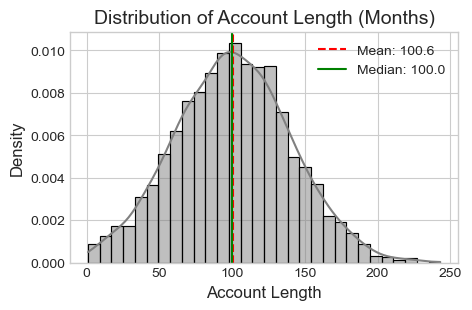

In [28]:
plt.figure(figsize=(5, 3))

# 히스토그램 + KDE 그래프
sns.histplot(df['Account length'], kde=True, color='grey', bins=30, stat="density")

# 평균(Mean)과 중앙값(Median) 표시
plt.axvline(df['Account length'].mean(), color='red', linestyle='--', label=f"Mean: {df['Account length'].mean():.1f}")
plt.axvline(df['Account length'].median(), color='green', linestyle='-', label=f"Median: {df['Account length'].median():.1f}")

plt.title('Distribution of Account Length (Months)', fontsize=14)
plt.xlabel('Account Length', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

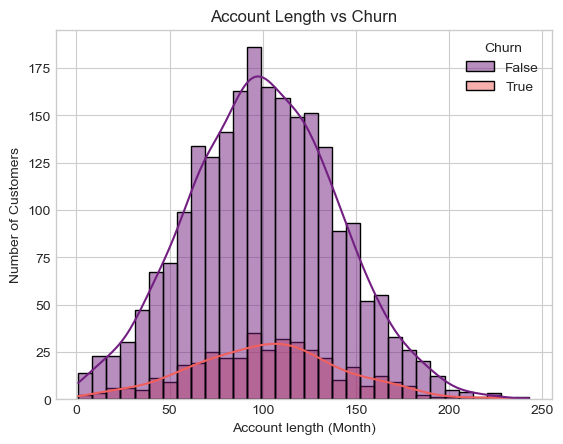

In [33]:
# 이탈한(Churn='Yes') 고객들의 이용 기간(tenure) 분포만 그리기
import seaborn as sns
sns.histplot(data=df, x='Account length', hue='Churn', kde=True, palette='magma')

plt.title('Account Length vs Churn')
plt.xlabel('Account length (Month)')
plt.ylabel('Number of Customers')
plt.show()

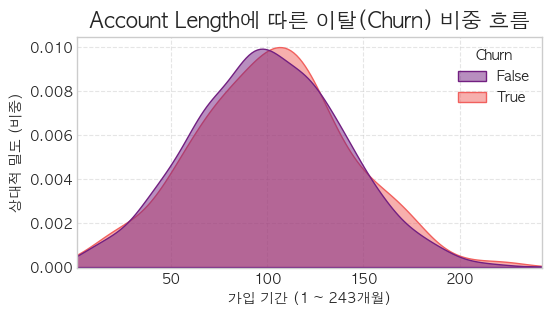

In [39]:
plt.rcParams['font.family'] = 'AppleGothic'

plt.figure(figsize=(6, 3))

# common_norm=False가 핵심입니다. 
# 전체 인원수 차이와 상관없이 '이탈자 내에서의 비중'과 '유지자 내에서의 비중'을 직접 비교합니다.
sns.kdeplot(data=df, x='Account length', hue='Churn', fill=True, common_norm=False, palette='magma', alpha=0.5)

plt.title('Account Length에 따른 이탈(Churn) 비중 흐름', fontsize=15)
plt.xlabel('가입 기간 (1 ~ 243개월)')
plt.ylabel('상대적 밀도 (비중)')
plt.xlim(1, 243) # 데이터 범위 고정
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

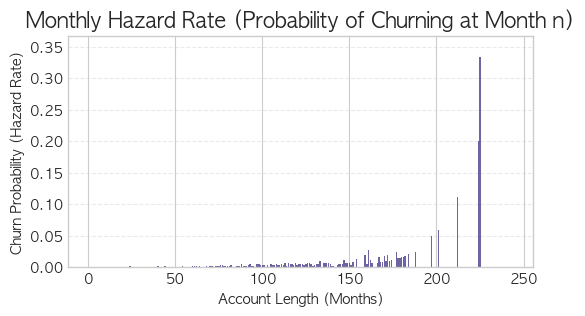

In [ ]:
# 1. 월별 이탈자(True)와 유지자(False) 수 카운트
# Churn 컬럼이 True/False라고 가정합니다.
stats = df.groupby('Account length')['Churn'].value_counts().unstack().fillna(0)

# 2. 분모(해당 월까지 살아남았던 총 인원) 계산
# n월의 분모 = (n월에 나간 사람) + (n월 이후까지 살아있는 모든 사람)
# 역순 누적합(Reverse Cumulative Sum)을 사용
survivors_at_each_month = stats.sum(axis=1)[::-1].cumsum()[::-1]

# 3. 이탈 비중(위험률) 계산
# n개월에 딱 나간 사람 수 / n개월까지 버텼던 사람 수
hazard_rate = stats[True] / survivors_at_each_month

# 4. 히스토그램(막대 그래프) 그리기
plt.figure(figsize=(6, 3))
plt.bar(hazard_rate.index, hazard_rate.values, color='darkslateblue', alpha=0.8, width=0.8)

plt.title('Monthly Hazard Rate (Probability of Churning at Month n)', fontsize=15)
plt.xlabel('Account Length (Months)')
plt.ylabel('Churn Probability (Hazard Rate)')
plt.ylim(0, hazard_rate.max() * 1.1) # Y축을 데이터에 맞게 최적화
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [45]:
# 1. 월별 이탈자(True)와 유지자(False) 수 집계
stats = df.groupby('Account length')['Churn'].value_counts().unstack().fillna(0)

# 2. 분모(해당 시점의 전체 고객 수) 계산
# 역순 누적합을 사용하여 '그 개월 차에 우리 고객이었던 총원'을 구함
total_at_start = stats.sum(axis=1)[::-1].cumsum()[::-1]

# 3. 표(DataFrame)로 정리
hazard_table = pd.DataFrame({
    'Month': stats.index,
    'Churned_at_n': stats[True].astype(int).values,    # 딱 n개월 쓰고 나간 사람
    'Survived_until_n': total_at_start.astype(int).values, # n개월차 시작 시점의 고객 총수
})

# 4. 이탈 비중(Hazard Rate) 계산 및 퍼센트 기입
hazard_table['Hazard_Rate(%)'] = (hazard_table['Churned_at_n'] / hazard_table['Survived_until_n'] * 100).round(2)

# 5. 결과 확인 (상위 20개 및 이탈률 높은 순 확인)
print("--- 가입 기간 초기 10개월 현황 ---")
print(hazard_table.head(10).to_string(index=False))

print("\n--- 이탈 위험도(%)가 가장 높은 TOP 10 구간 ---")
print(hazard_table.sort_values(by='Hazard_Rate(%)', ascending=False).head(10).to_string(index=False))

--- 가입 기간 초기 10개월 현황 ---
 Month  Churned_at_n  Survived_until_n  Hazard_Rate(%)
     1             1              2666            0.04
     2             1              2660            0.04
     3             0              2659            0.00
     4             0              2655            0.00
     5             0              2654            0.00
     6             0              2653            0.00
     7             0              2652            0.00
     8             0              2651            0.00
     9             0              2650            0.00
    10             0              2647            0.00

--- 이탈 위험도(%)가 가장 높은 TOP 10 구간 ---
 Month  Churned_at_n  Survived_until_n  Hazard_Rate(%)
   225             1                 3           33.33
   224             1                 5           20.00
   212             1                 9           11.11
   201             1                17            5.88
   197             1                20            5.00
   1

아웃라이어 거르기
- 변동계수(CV, Coefficient of Variation) 룰
- 신뢰구간(Confidence Interval) 오차 범위 룰

### 상관 관계 파악하기

--- [전체 21개 변수] Churn과의 상관계수 순위 ---
Churn_numeric             1.000000
Churn                     1.000000
International plan        0.277489
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
State                     0.000430
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Voice mail plan          -0.099291
Name: Churn, dtype: float64


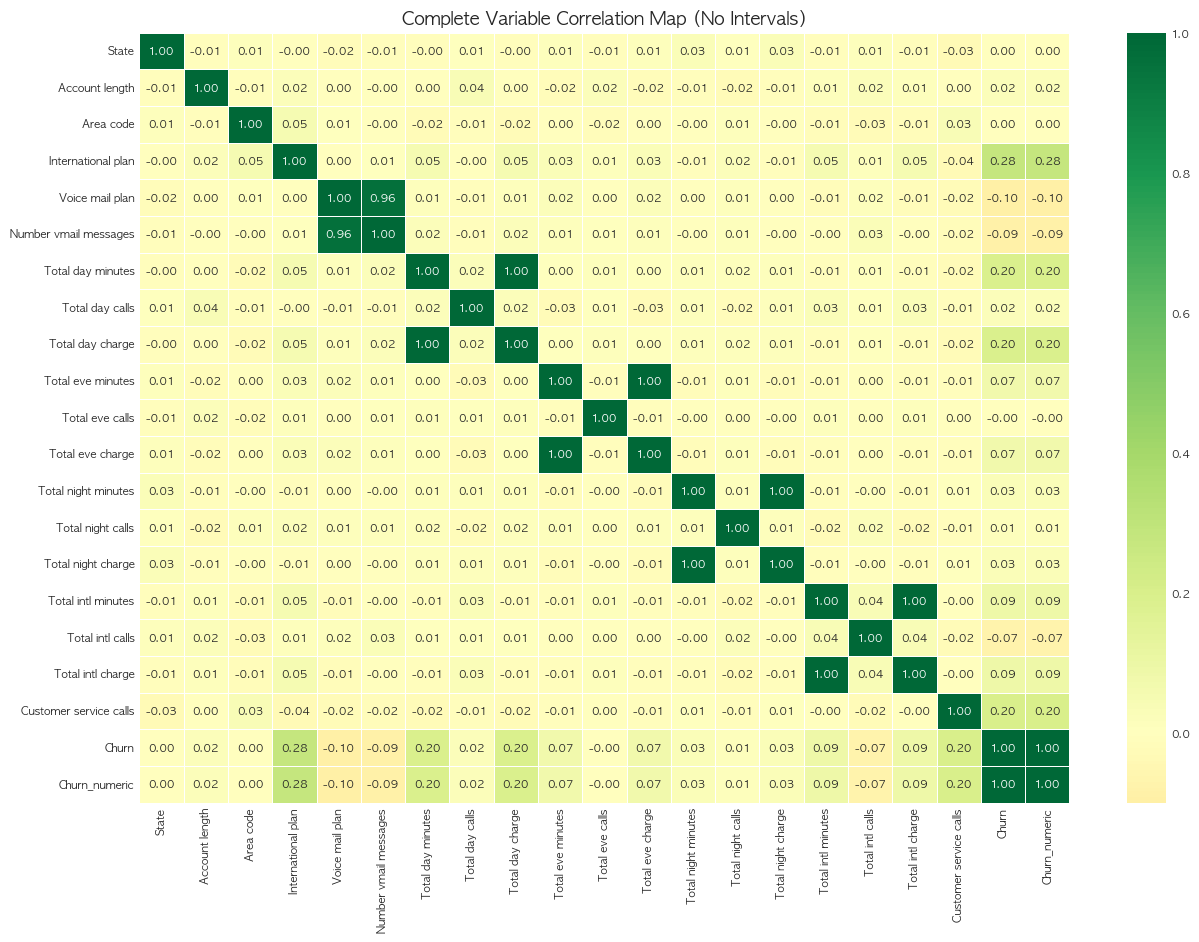

In [90]:
# 1. 데이터 복사 및 수치화
df_numeric = df.copy()

# 범주형 변수 -> 숫자 변환
df_numeric['International plan'] = df_numeric['International plan'].map({'Yes': 1, 'No': 0})
df_numeric['Voice mail plan'] = df_numeric['Voice mail plan'].map({'Yes': 1, 'No': 0})
df_numeric['Churn'] = df_numeric['Churn'].astype(int)

# 문자열(State) -> 숫자 변환 (누락 방지)
le = LabelEncoder()
df_numeric['State'] = le.fit_transform(df_numeric['State'])

# 2. [중요] 숫자(int, float)와 불리언 데이터만 선택 (Interval 객체 자동 제외)
df_final = df_numeric.select_dtypes(include=['number', 'bool'])

# 3. 상관계수 계산 및 Churn 기준 정렬
full_corr = df_final.corr()
churn_corr_sorted = full_corr['Churn'].sort_values(ascending=False)

print("--- [전체 21개 변수] Churn과의 상관계수 순위 ---")
print(churn_corr_sorted)

# 4. 히트맵 시각화
plt.figure(figsize=(15, 10))
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Complete Variable Correlation Map (No Intervals)', fontsize=13)
plt.show()

### Customer service calls

In [52]:
# 상담 횟수에 따른 그룹 정의
def categorize_calls(calls):
    if calls <= 1: return '0-1: Silent'
    elif calls <= 3: return '2-3: Interacting'
    else: return '4+: High-Risk'

df['Call_Group'] = df['Customer service calls'].apply(categorize_calls)

# 그룹별 이탈률 확인
group_churn = df.groupby('Call_Group')['Churn_numeric'].mean().sort_index()
print(group_churn)

Call_Group
0-1: Silent         0.118667
2-3: Interacting    0.103556
4+: High-Risk       0.528571
Name: Churn_numeric, dtype: float64


#### Call_Group별 churn rate:
- 0-1: Silent         0.118667   # 약 11.9%	평균적인 수준의 이탈 
- 2-3: Interacting    0.103556   # 약 10.4%	오히려 상담을 적당히 한 그룹이 가장 안 나간다! 
- 4+: High-Risk       0.528571   # 약 52.9%	위험 신호: 전화를 4번 넘게 하면 둘 중 한 명은 무조건 나간다

!! 고객이 3번째 전화를 거는 순간을 '마지막 기회'로 잡아야 한다.

In [53]:
# 분석하고 싶은 주요 지표들 선택
features = ['Account length', 'Total day charge', 'Total eve charge', 'Total night charge', 'Churn_numeric']

# Call_Group별로 평균값 계산
call_group_stats = df.groupby('Call_Group')[features].mean()

# 보기 좋게 퍼센트와 소수점 정리
call_group_stats['Churn_Rate(%)'] = (call_group_stats['Churn_numeric'] * 100).round(2)
call_group_stats = call_group_stats.drop(columns=['Churn_numeric'])

print("--- Call Group별 주요 지표 평균값 ---")
print(call_group_stats)

--- Call Group별 주요 지표 평균값 ---
                  Account length  Total day charge  Total eve charge  \
Call_Group                                                             
0-1: Silent           100.847333         30.807367         17.109380   
2-3: Interacting      100.173640         30.181318         16.895293   
4+: High-Risk         101.033333         29.912762         17.115238   

                  Total night charge  Churn_Rate(%)  
Call_Group                                           
0-1: Silent                 9.020520          11.87  
2-3: Interacting            9.118358          10.36  
4+: High-Risk               8.983524          52.86  


#### 상담 그룹별 요금 분포 확인

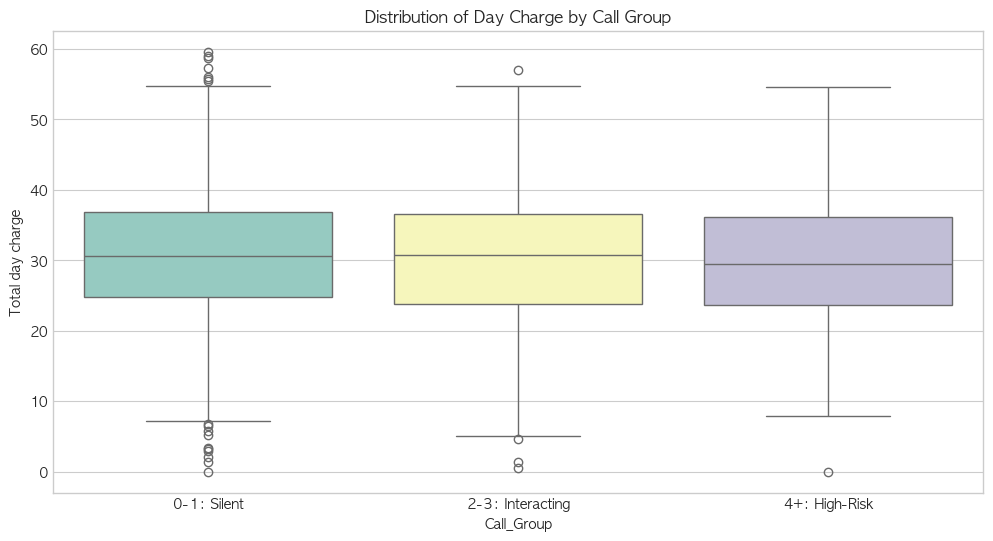

In [54]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Call_Group', y='Total day charge', palette='Set3')
plt.title('Distribution of Day Charge by Call Group')
plt.show()

In [58]:
df['Customer service calls'].unique()

array([1, 0, 2, 3, 4, 5, 7, 9, 6, 8])

In [59]:
df['Customer service calls'].value_counts()

Customer service calls
1    945
2    608
0    555
3    348
4    133
5     49
6     17
7      8
9      2
8      1
Name: count, dtype: int64

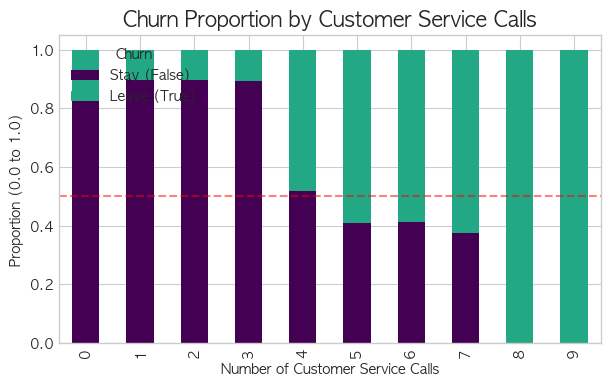

In [76]:
# 1. 호출 횟수별 이탈 여부 비율 계산 (normalize='index'가 핵심!)
cross_tab = pd.crosstab(df['Customer service calls'], df['Churn_numeric'], normalize='index')

# 2. 누적 막대 그래프 그리기
cross_tab.plot(kind='bar', 
               stacked=True, 
               figsize=(7, 4), 
               color=['#440154', '#22a884']) # 보라색, 초록색 지정

# 3. 그래프 꾸미기
plt.title('Churn Proportion by Customer Service Calls', fontsize=15)
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Proportion (0.0 to 1.0)')
plt.legend(title='Churn', labels=['Stay (False)', 'Leave (True)'], loc='upper left')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5) # 50% 지점에 가이드선

plt.show()

### International Plan 및 Voice Mail Plan과 churn과의 관계

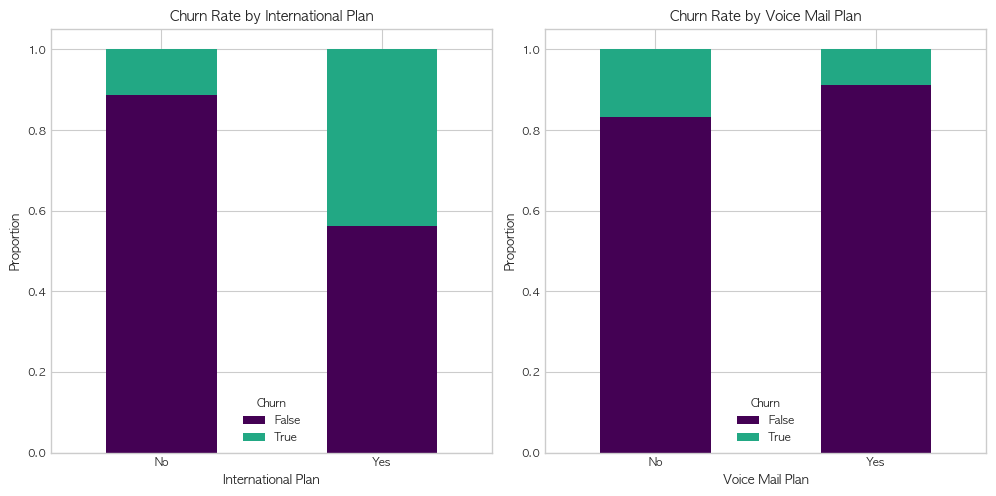

In [79]:
# 1. 시각화 스타일 및 폰트 설정
plt.rc('font', size=8) # 폰트 사이즈를 작게 설정
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 2. International plan vs Churn 비율 계산 및 시각화
int_plan_ct = pd.crosstab(df['International plan'], df['Churn'], normalize='index')
int_plan_ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#440154', '#22a884'], rot=0)
axes[0].set_title('Churn Rate by International Plan', fontsize=10)
axes[0].set_xlabel('International Plan', fontsize=9)
axes[0].set_ylabel('Proportion', fontsize=9)

# 3. Voice mail plan vs Churn 비율 계산 및 시각화
vmail_plan_ct = pd.crosstab(df['Voice mail plan'], df['Churn'], normalize='index')
vmail_plan_ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#440154', '#22a884'], rot=0)
axes[1].set_title('Churn Rate by Voice Mail Plan', fontsize=10)
axes[1].set_xlabel('Voice Mail Plan', fontsize=9)
axes[1].set_ylabel('Proportion', fontsize=9)

plt.tight_layout()
plt.show()

[해석]
그래프 상으로, 국제 요금 가입자가 미가입자 대비 이탈률이 크게 보이고, 음성메일 가입자는 미가입자가 더 이탈률이 많아 보인다.
<br> 이 차이가 통계적으로 유의미한지 검증해보겠다:

#### 유의성 검증

In [82]:
from scipy.stats import chi2_contingency

# 1. International Plan 검증 (카이제곱 검정)
int_ct = pd.crosstab(df['International plan'], df['Churn_numeric'])
chi2_int, p_int, _, _ = chi2_contingency(int_ct)

# 2. Voice Mail Plan 검증 (카이제곱 검정)
vmail_ct = pd.crosstab(df['Voice mail plan'], df['Churn_numeric'])
chi2_vmail, p_vmail, _, _ = chi2_contingency(vmail_ct)

print(f"[International Plan] P-value: {p_int:.10f}") 
# 결과 해석: 0.05보다 훨씬 작으면 "이탈과 매우 깊은 관계가 있음"

print(f"[Voice Mail Plan] P-value: {p_vmail:.10f}")
# 결과 해석: 0.05보다 크면 "이탈과 별 관계 없음 (우연일 가능성 높음)"

[International Plan] P-value: 0.0000000000
[Voice Mail Plan] P-value: 0.0000004080


In [86]:
# 상관관계를 볼 주요 변수 선택
# (International plan과 Churn은 불리언/범주형이므로 수치형으로 변환 후 계산해야 합니다)
target_cols = [
    'International plan', 'Total intl minutes', 'Total intl calls', 
    'Total intl charge', 'Customer service calls', 'Churn'
]

# 데이터 타입 변환 (Yes/No -> 1/0, True/False -> 1/0)
corr_df = df[target_cols].copy()
corr_df['International plan'] = corr_df['International plan'].map({'Yes': 1, 'No': 0})
corr_df['Churn'] = corr_df['Churn'].astype(int)

# 상관계수 행렬 계산
correlation_matrix = corr_df.corr()

print("국제 요금 관련 변수 간 상관계수:")
print(correlation_matrix['Churn'].sort_values(ascending=False))

국제 요금 관련 변수 간 상관계수:
Churn                     1.000000
International plan        0.277489
Customer service calls    0.202590
Total intl charge         0.086216
Total intl minutes        0.086204
Total intl calls         -0.069882
Name: Churn, dtype: float64


### Total day charge과 고객 이탈과의 관계

In [138]:
# 기초 통계 확인
print("--- [Churn 여부에 따른 Total day charge 통계] ---")
print(df.groupby('Churn')['Total day charge'].agg(['mean', 'std', 'median', 'count']))

--- [Churn 여부에 따른 Total day charge 통계] ---
            mean        std  median  count
Churn                                     
False  29.768266   8.517839   30.24   2278
True   34.881340  11.643479   36.54    388


Text(0.5, 1.0, 'Boxplot: Day Charge vs Churn')

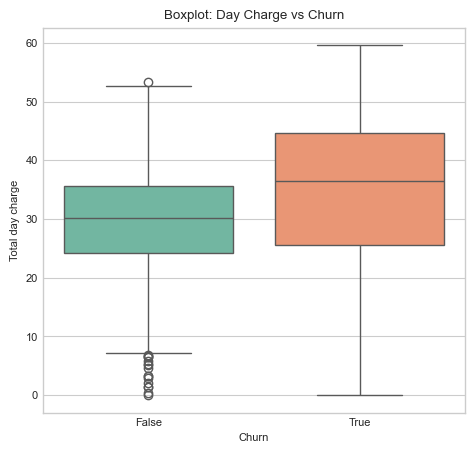

In [139]:
# 시각화
plt.figure(figsize=(12, 5))

# Boxplot: 중앙값과 이상치(Outliers) 확인
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='Total day charge', data=df, palette='Set2')
plt.title('Boxplot: Day Charge vs Churn')

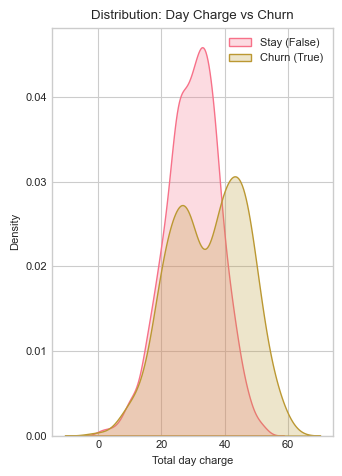

In [140]:
# KDE Plot: 분포의 차이를 시각적으로 확인
plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Churn'] == False]['Total day charge'], label='Stay (False)', fill=True)
sns.kdeplot(df[df['Churn'] == True]['Total day charge'], label='Churn (True)', fill=True)
plt.title('Distribution: Day Charge vs Churn')
plt.legend()

plt.tight_layout()
plt.show()

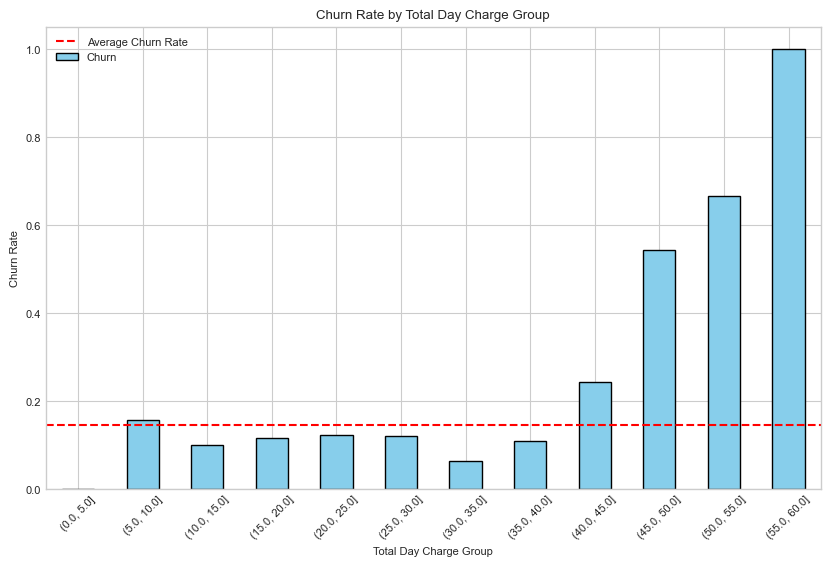

In [141]:
# 2. 요금 구간(Bin) 생성 (5단위로 구분)
# 단순히 밀도만 보는 게 아니라 실제 숫자로 확인하기 위함입니다.
bins = np.arange(0, df['Total day charge'].max() + 5, 5)
df['charge_group'] = pd.cut(df['Total day charge'], bins=bins)

# 3. 구간별 이탈률 계산
churn_rate_by_charge = df.groupby('charge_group')['Churn'].mean()

# 4. 시각화: 요금 구간에 따른 이탈률 변화
plt.figure(figsize=(10, 6))
churn_rate_by_charge.plot(kind='bar', color='skyblue', edgecolor='black')
plt.axhline(df['Churn'].mean(), color='red', linestyle='--', label='Average Churn Rate')
plt.title('Churn Rate by Total Day Charge Group')
plt.xlabel('Total Day Charge Group')
plt.ylabel('Churn Rate')
plt.legend()
plt.xticks(rotation=45)
plt.show()

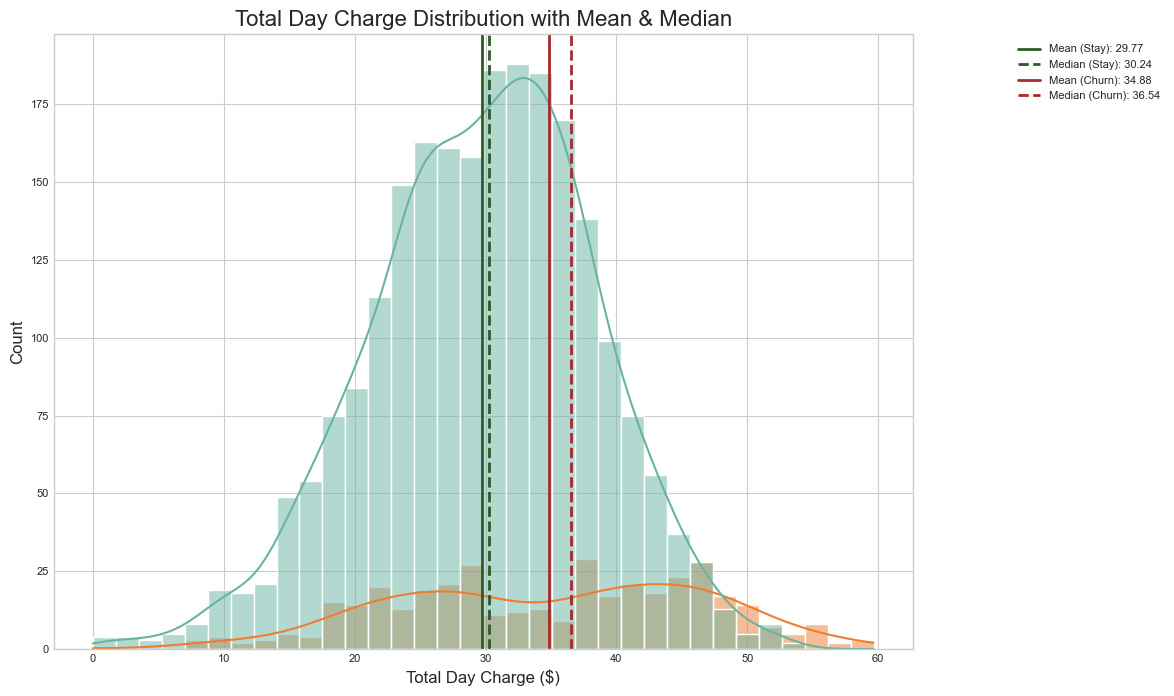

In [142]:
# 2. 스타일 및 폰트 설정
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# 3. 히스토그램 그리기
ax = sns.histplot(data=df, x='Total day charge', hue='Churn', kde=True, 
                  element="bars", palette={False: "#69b3a2", True: "#ed7d31"}, alpha=0.5)

# 4. 그룹별 평균 및 중앙값 계산 및 선 긋기
colors = {False: "#2d5a27", True: "#a52a2a"} # 선이 잘 보이도록 조금 더 진한 색상 사용

for churn_status in [False, True]:
    subset = df[df['Churn'] == churn_status]['Total day charge']
    mean_val = subset.mean()
    median_val = subset.median()
    color = colors[churn_status]
    label_suffix = "(Churn)" if churn_status else "(Stay)"
    
    # 평균선 (실선)
    plt.axvline(mean_val, color=color, linestyle='-', linewidth=2, 
                label=f'Mean {label_suffix}: {mean_val:.2f}')
    
    # 중앙값선 (점선)
    plt.axvline(median_val, color=color, linestyle='--', linewidth=2, 
                label=f'Median {label_suffix}: {median_val:.2f}')

# 5. 차트 꾸미기
plt.title('Total Day Charge Distribution with Mean & Median', fontsize=16)
plt.xlabel('Total Day Charge ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1)) # 범례를 그래프 밖으로 이동
plt.tight_layout()

plt.show()

In [143]:
df['Total day charge'].describe()

count    2666.000000
mean       30.512404
std         9.215733
min         0.000000
25%        24.380000
50%        30.590000
75%        36.700000
max        59.640000
Name: Total day charge, dtype: float64

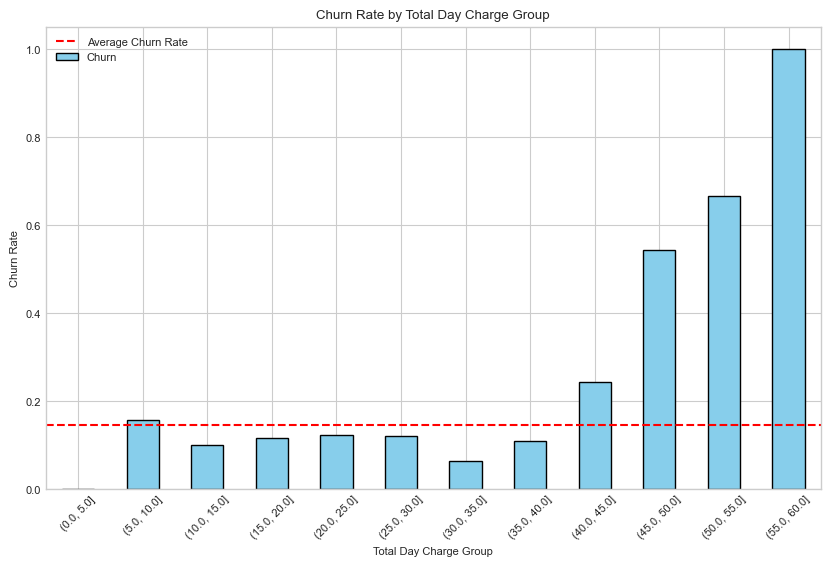

In [144]:
# 요금 구간(Bin) 생성 (5단위로 구분)
# 단순히 밀도만 보는 게 아니라 실제 숫자로 확인하기 위함입니다.
bins = np.arange(0, df['Total day charge'].max() + 5, 5)
df['charge_group'] = pd.cut(df['Total day charge'], bins=bins)

# 구간별 이탈률 계산
churn_rate_by_charge = df.groupby('charge_group')['Churn'].mean()

# 4. 시각화: 요금 구간에 따른 이탈률 변화
plt.figure(figsize=(10, 6))
churn_rate_by_charge.plot(kind='bar', color='skyblue', edgecolor='black')
plt.axhline(df['Churn'].mean(), color='red', linestyle='--', label='Average Churn Rate')
plt.title('Churn Rate by Total Day Charge Group')
plt.xlabel('Total Day Charge Group')
plt.ylabel('Churn Rate')
plt.legend()
plt.xticks(rotation=45)
plt.show()


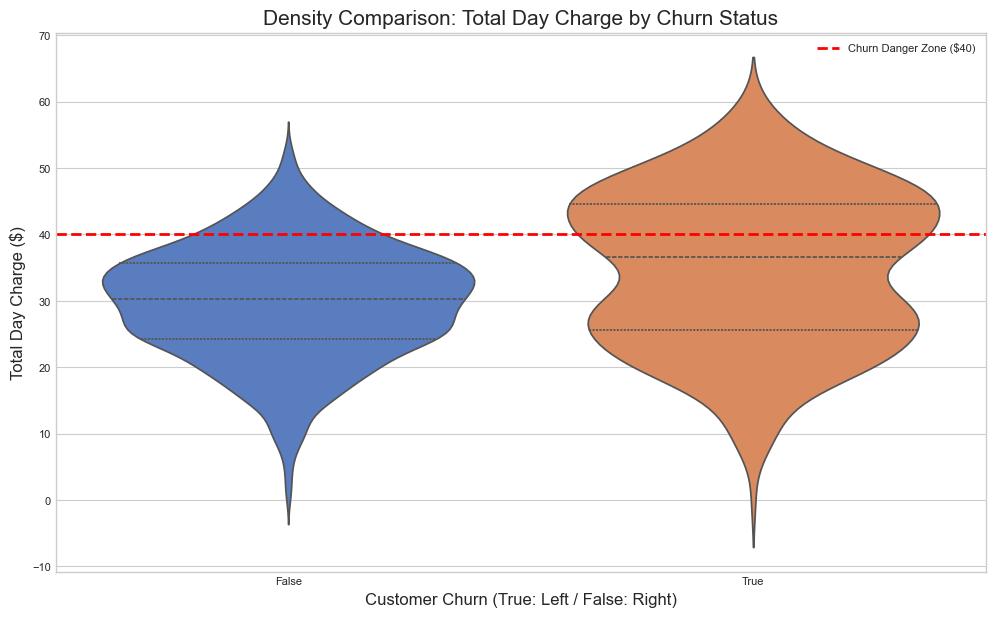

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화 스타일 설정
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 2. 바이올린 플롯 생성 (Churn 여부에 따른 요금 분포)
sns.violinplot(data=df, x='Churn', y='Total day charge', 
               palette='muted', split=False, inner="quartile")

# 3. 데드크로스(Deadcross) 구간 강조 (약 38~40달러 구간)
plt.axhline(y=40, color='red', linestyle='--', linewidth=2, label='Churn Danger Zone ($40)')

# 4. 그래프 제목 및 라벨
plt.title('Density Comparison: Total Day Charge by Churn Status', fontsize=15)
plt.xlabel('Customer Churn (True: Left / False: Right)', fontsize=12)
plt.ylabel('Total Day Charge ($)', fontsize=12)
plt.legend()

plt.show()

In [146]:
# 다중공선성 계산을 위한 필수 라이브러리 임포트
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 만약 statsmodels가 설치되어 있지 않다면 아래 명령어를 터미널에 입력하세요.
# !pip install statsmodels

# 1. 수치형(숫자) 데이터 타입만 선택
# select_dtypes를 사용하면 문자열이나 객체 타입을 자동으로 제외합니다.
vif_features = df_numeric.select_dtypes(include=['number'])

# 2. 결측치(NaN)가 있으면 VIF 계산이 불가능하므로 제거
vif_features = vif_features.dropna()

# 3. 상수항(Intercept) 추가 (VIF 계산의 정확도를 위해 권장)
# statsmodels의 VIF는 상수항이 없을 경우 수치가 왜곡될 수 있습니다.
from statsmodels.tools.tools import add_constant
vif_features_with_const = add_constant(vif_features)

# 4. VIF 계산 실행
vif_report = get_vif_report(vif_features_with_const)
print(vif_report)

                   Feature           VIF
20                   Churn           inf
21           Churn_numeric           inf
9         Total day charge  1.041539e+07
7        Total day minutes  1.041538e+07
10       Total eve minutes  2.296472e+06
12        Total eve charge  2.296471e+06
13     Total night minutes  6.483137e+05
15      Total night charge  6.483132e+05
18       Total intl charge  6.842708e+04
16      Total intl minutes  6.842695e+04
0                    const  2.582919e+02
5          Voice mail plan  1.204592e+01
6    Number vmail messages  1.201597e+01
4       International plan  1.103459e+00
19  Customer service calls  1.063082e+00
17        Total intl calls  1.012525e+00
3                Area code  1.010045e+00
8          Total day calls  1.005833e+00
2           Account length  1.005115e+00
14       Total night calls  1.004023e+00
1                    State  1.003526e+00
11         Total eve calls  1.002710e+00


In [147]:
# 1. 국제 요금제 가입 여부별 전체 요금(Total_Charge) 기초 통계
plan_cost_comparison = df.groupby('International plan')['Total day charge'].describe().round(2)
plan_cost_comparison['Churn_Rate(%)'] = df.groupby('International plan')['Churn'].mean() * 100

print("--- [표 1] 국제 요금제 가입 여부별 비용 및 이탈률 비교 ---")
print(plan_cost_comparison[['mean', '50%', 'max', 'Churn_Rate(%)']])

--- [표 1] 국제 요금제 가입 여부별 비용 및 이탈률 비교 ---
                     mean    50%    max  Churn_Rate(%)
International plan                                    
No                  30.36  30.49  59.64      11.268781
Yes                 31.87  31.46  58.96      43.703704


In [148]:
# 2. 국제 요금제 가입자만 필터링
intl_subscribers = df[df['International plan'] == 'Yes'].copy()

# 3. 요금 세그먼트 생성 (예: 10달러 단위)
bins = list(range(30, 111, 10))
labels = [f'${i}-{i+10}' for i in bins[:-1]]
intl_subscribers['Cost_Segment'] = pd.cut(intl_subscribers['Total day charge'], bins=bins, labels=labels)

# 4. 세그먼트별 이탈자 수 및 이탈률 분석
segment_analysis = intl_subscribers.groupby('Cost_Segment', observed=True).agg({
    'Churn': ['count', 'sum', 'mean']
})
segment_analysis.columns = ['Total_Customers', 'Churn_Count', 'Churn_Rate']
segment_analysis['Churn_Rate'] = (segment_analysis['Churn_Rate'] * 100).round(2)

print("\n--- [표 2] 국제 요금제 가입자 내 가격 세그먼트별 이탈 현황 ---")
print(segment_analysis)


--- [표 2] 국제 요금제 가입자 내 가격 세그먼트별 이탈 현황 ---
              Total_Customers  Churn_Count  Churn_Rate
Cost_Segment                                          
$30-40                     89           33       37.08
$40-50                     53           31       58.49
$50-60                      6            4       66.67


In [149]:
# 1. 상관계수 계산을 위한 데이터 준비
# Churn을 숫자(0, 1)로 변환한 'Churn_numeric'이 있다고 가정합니다.
charge_features = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
correlations = df[charge_features + ['Churn_numeric']].corr()['Churn_numeric'].sort_values(ascending=False)

# 'Churn_numeric' 자기 자신과의 상관계수는 제외
correlations = correlations.drop('Churn_numeric')
print(correlations)

Total day charge      0.195689
Total intl charge     0.086216
Total eve charge      0.072893
Total night charge    0.033635
Name: Churn_numeric, dtype: float64


In [150]:
# 1. 4가지 요금을 모두 더한 Total_Charge 생성
df['Total_Charge'] = (df['Total day charge'] + df['Total eve charge'] + 
                      df['Total night charge'] + df['Total intl charge'])

# 2. 국제 요금제 가입 여부 및 이탈 여부에 따른 총 요금 평균 비교
total_analysis = df.groupby(['International plan', 'Churn'])['Total_Charge'].mean().unstack().round(2)

print("--- [국제 요금제 x 이탈 여부] 평균 총 요금 ($) ---")
print(total_analysis)

--- [국제 요금제 x 이탈 여부] 평균 총 요금 ($) ---
Churn               False  True 
International plan              
No                  58.33  65.71
Yes                 59.77  62.85


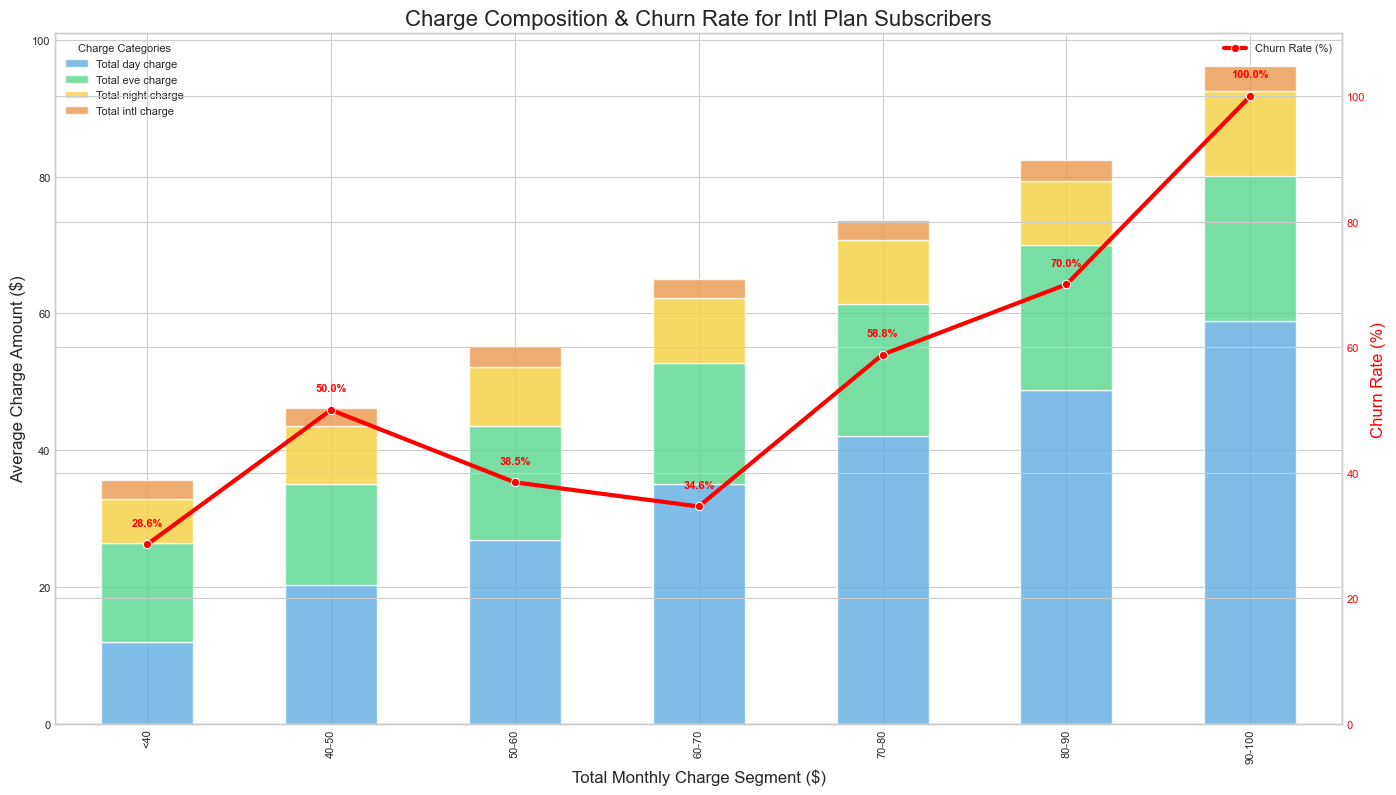

In [151]:
# 1. 전체 요금(Total_Charge) 생성
df['Total_Charge'] = df['Total day charge'] + df['Total eve charge'] + \
                     df['Total night charge'] + df['Total intl charge']

# 2. 요금 세그먼트(Charge_Segment) 생성 (전체 df에 먼저 적용)
bins = [0, 40, 50, 60, 70, 80, 90, 100, 150]
labels = ['<40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100', '100+']
df['Charge_Segment'] = pd.cut(df['Total_Charge'], bins=bins, labels=labels)

# 3. 국제 요금제 가입자만 필터링
intl_subs = df[df['International plan'] == 'Yes'].copy()

# 4. 세그먼트별 각 요금 항목의 '평균값'과 '이탈률' 계산
charge_cols = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
segment_composition = intl_subs.groupby('Charge_Segment', observed=True).agg({
    **{col: 'mean' for col in charge_cols},
    'Churn': 'mean'
}).reset_index()

segment_composition['churn_rate'] = segment_composition['Churn'] * 100

# 5. 시각화 시작
fig, ax1 = plt.subplots(figsize=(14, 8))

# 누적 막대그래프 (요금 항목별 색상 표시)
colors = ['#5DADE2', '#58D68D', '#F4D03F', '#EB984E'] # Day, Eve, Night, Intl 순서
segment_composition.set_index('Charge_Segment')[charge_cols].plot(
    kind='bar', stacked=True, ax=ax1, color=colors, alpha=0.8
)

ax1.set_ylabel('Average Charge Amount ($)', fontsize=12)
ax1.set_xlabel('Total Monthly Charge Segment ($)', fontsize=12)
ax1.set_title('Charge Composition & Churn Rate for Intl Plan Subscribers', fontsize=16)
ax1.legend(title='Charge Categories', loc='upper left')

# 6. 이탈률 꺾은선 그래프 추가 (오른쪽 축)
ax2 = ax1.twinx()
# x축 위치를 맞추기 위해 range(len(...)) 사용
sns.lineplot(x=range(len(segment_composition)), y=segment_composition['churn_rate'], 
             color='red', marker='o', linewidth=3, ax=ax2, label='Churn Rate (%)')

ax2.set_ylabel('Churn Rate (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# 이탈률 수치 표시
for i, rate in enumerate(segment_composition['churn_rate']):
    ax2.text(i, rate + 3, f'{rate:.1f}%', color='red', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [152]:
# 1. 시간대별 분당 가격(단가) 변수 생성
# Charge / Minutes를 통해 1분당 실제 지불 금액을 산출합니다.
df['Day_Rate'] = df['Total day charge'] / df['Total day minutes']
df['Eve_Rate'] = df['Total eve charge'] / df['Total eve minutes']
df['Night_Rate'] = df['Total night charge'] / df['Total night minutes']
df['Intl_Rate'] = df['Total intl charge'] / df['Total intl minutes']

# 2. 국제 요금제 가입 여부 및 이탈 여부별 평균 단가 비교
rate_analysis = df.groupby(['International plan', 'Churn'])[['Day_Rate', 'Intl_Rate']].mean().round(4)

print("--- [국제 요금제 x 이탈 여부] 분당 평균 단가 비교 ---")
print(rate_analysis)

--- [국제 요금제 x 이탈 여부] 분당 평균 단가 비교 ---
                          Day_Rate  Intl_Rate
International plan Churn                     
No                 False      0.17     0.2701
                   True       0.17     0.2701
Yes                False      0.17     0.2701
                   True       0.17     0.2700


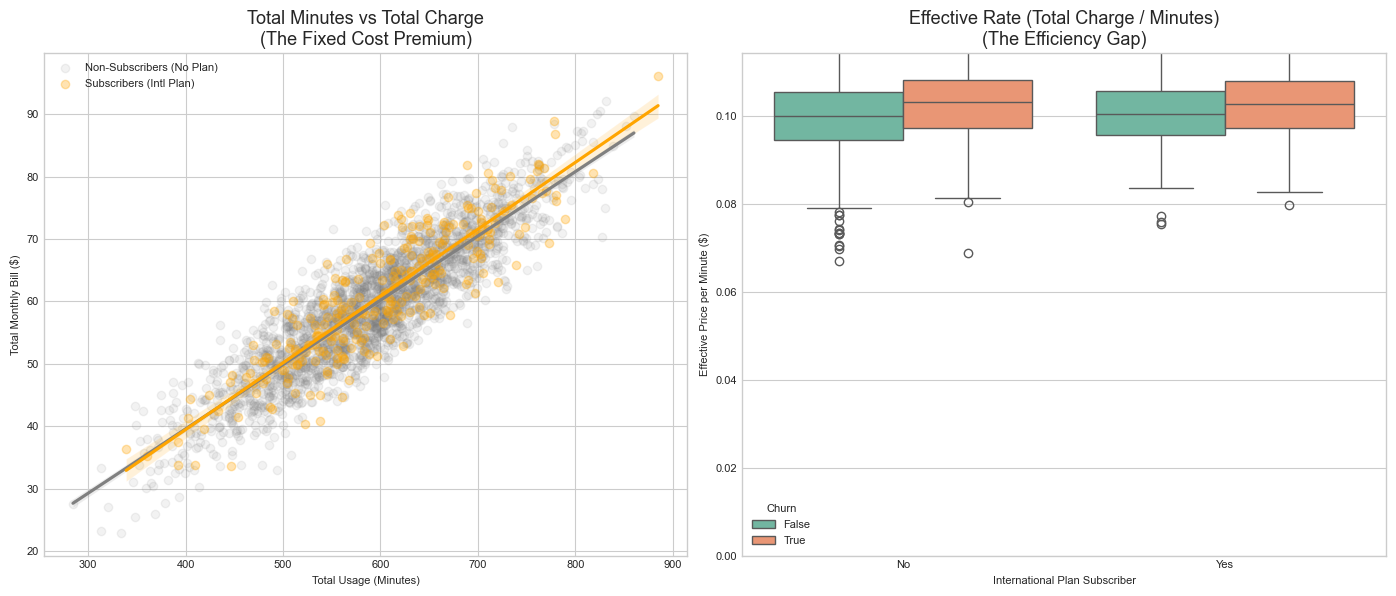

In [153]:
# 1. 필수 파생 변수 생성
# 모든 시간대 사용분과 요금을 합산합니다.
df['Total_Minutes'] = df['Total day minutes'] + df['Total eve minutes'] + \
                      df['Total night minutes'] + df['Total intl minutes']
df['Total_Charge'] = df['Total day charge'] + df['Total eve charge'] + \
                     df['Total night charge'] + df['Total intl charge']

# 실질 단가(Effective Rate): 총 요금을 총 사용 시간으로 나눈 값 (1분당 실제 지불액)
# 사용량이 0인 경우를 대비해 분모가 0이 되지 않도록 처리합니다.
df['Effective_Rate'] = df['Total_Charge'] / df.Total_Minutes.replace(0, np.nan)

# 2. 시각화 설정
plt.figure(figsize=(14, 6))

# --- [좌측 그래프] 사용량 대비 총 요금 (고정비 확인) ---
plt.subplot(1, 2, 1)
# 가입 여부별로 회귀선을 그려서 Y축 절편(기본료)의 차이를 확인합니다.
sns.regplot(data=df[df['International plan']=='No'], x='Total_Minutes', y='Total_Charge', 
            scatter_kws={'alpha':0.1}, label='Non-Subscribers (No Plan)', color='grey')
sns.regplot(data=df[df['International plan']=='Yes'], x='Total_Minutes', y='Total_Charge', 
            scatter_kws={'alpha':0.3}, label='Subscribers (Intl Plan)', color='orange')

plt.title('Total Minutes vs Total Charge\n(The Fixed Cost Premium)', fontsize=13)
plt.xlabel('Total Usage (Minutes)')
plt.ylabel('Total Monthly Bill ($)')
plt.legend()

# --- [우측 그래프] 실질 단가 비교 (가성비 확인) ---
plt.subplot(1, 2, 2)
# 가입자가 미가입자보다 1분당 얼마나 더 비싸게 지불하는지 이탈 여부와 함께 봅니다.
sns.boxplot(data=df, x='International plan', y='Effective_Rate', hue='Churn', palette='Set2')

plt.title('Effective Rate (Total Charge / Minutes)\n(The Efficiency Gap)', fontsize=13)
plt.xlabel('International Plan Subscriber')
plt.ylabel('Effective Price per Minute ($)')
plt.ylim(0, df['Effective_Rate'].quantile(0.95)) # 극단값 제외하고 보기 좋게 조정

plt.tight_layout()
plt.show()

In [154]:
# 1. 국제 요금제 가입 여부별 고객 센터 통화 평균 및 이탈률
cs_call_analysis = df.groupby(['International plan', 'Churn'])['Customer service calls'].mean().unstack().round(2)

print("--- [국제 요금제 x 이탈 여부] 평균 고객 센터 통화 횟수 ---")
print(cs_call_analysis)

--- [국제 요금제 x 이탈 여부] 평균 고객 센터 통화 횟수 ---
Churn               False  True 
International plan              
No                   1.46   2.51
Yes                  1.35   1.52


In [155]:
from scipy import stats

# 1. 데이터 분리
churn_yes = df[df['Churn'] == True]['Total day charge']
churn_no = df[df['Churn'] == False]['Total day charge']

# 2. 등분산성 검정 (Levene's test)
# 두 집단의 분산이 같은지 먼저 확인합니다.
levene_stat, levene_p = stats.levene(churn_yes, churn_no)

# 3. t-test 수행
# 등분산성 검정 결과(levene_p)가 0.05보다 작으면 equal_var=False (Welch's t-test)를 사용합니다.
t_stat, p_val = stats.ttest_ind(churn_yes, churn_no, equal_var=(levene_p > 0.05))

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

t-statistic: 8.2808
p-value: 0.0000


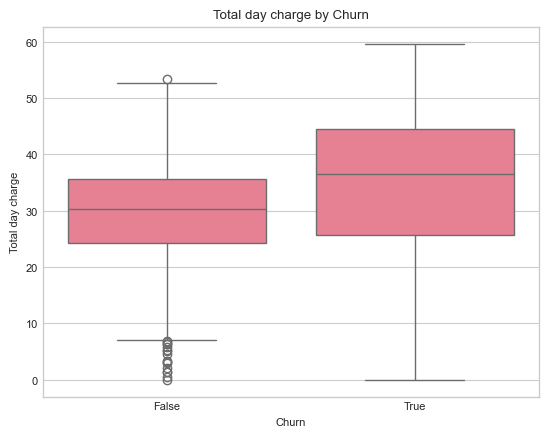

In [156]:
sns.boxplot(x='Churn', y='Total day charge', data=df)
plt.title('Total day charge by Churn')
plt.show()

In [157]:
charge_cols = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
results = []

for col in charge_cols:
    churn_yes = df[df['Churn'] == True][col]
    churn_no = df[df['Churn'] == False][col]
    
    t_stat, p_val = stats.ttest_ind(churn_yes, churn_no, equal_var=False)
    results.append({'Variable': col, 't-statistic': abs(t_stat), 'p-value': p_val})

# t-statistic 기준 내림차순 정렬
results_df = pd.DataFrame(results).sort_values(by='t-statistic', ascending=False)
print(results_df)

             Variable  t-statistic       p-value
0    Total day charge     8.280801  1.342382e-15
3   Total intl charge     4.475092  9.360700e-06
1    Total eve charge     3.770047  1.816694e-04
2  Total night charge     1.832088  6.747720e-02


In [158]:
# 주별 이탈률: 차이가 크지 않음.
state_churn_rate = df.groupby('State')['Churn'].mean().sort_values(ascending=False)
print(state_churn_rate.head()) # 이탈률이 가장 높은 주 TOP 5

State
TX    0.290909
NJ    0.280000
AR    0.234043
MD    0.233333
MS    0.229167
Name: Churn, dtype: float64


## 4.모델링

모델링의 목적: 고객 이탈 확률을 예측하고, 액션을 결정하기 위함

**1. Logistic Regression: "이탈의 결정적 원인(Impact) 파악"**
이 모델은 예측 성능 자체보다 **설명력(Explainability)**을 목적으로 사용한다.
각 변수가 고객 이탈에 어떤 방향으로, 얼마나 직접적인 영향을 미치는지를
**Odds Ratio(오즈비)**를 통해 정량적으로 해석한다. (= 확률 + 계수로 “왜 이탈하는지”를 예측)

**2. Random Forest: "주요 변수 간의 비선형적 관계 파악"**

이 모델은 변수 간의 비선형 상호작용을 학습하여, EDA에서 발견한 특정 임계점(예: $40 요금 구간, 상담 3~4회, 가입 100개월)이 실제로 이탈을 구분하는 기준으로 작동하는지를 검증하는 성능 중심 모델이다.(= “누가 진짜 위험한지”를 최대한 놓치지 않고 예측)

**3. K-Nearest Neighbors — "이탈 성향 고객 프로파일링"**
이탈 고객과의 행동·요금 유사도를 기반으로, 해당 고객이 ‘이탈 성향 고객 군집’에 속할 확률을 예측한다. 



### 1. Logistic Regression:

#### 1. 데이터 로드, 전처리 통합,특정 변수만 선택하여 데이터프레임 재구성

In [166]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. 파일 경로 설정
train_path = 'data/churn-bigml-80.csv'
test_path = 'data/churn-bigml-20.csv'

# 2. 데이터 로드
train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)

# 3. 전처리 함수 정의 (두 데이터에 똑같이 적용)
def preprocess_churn(df):
    # 범주형 -> 숫자 변환
    df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
    df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)
    
    # State 라벨 인코딩
    le = LabelEncoder()
    df['State'] = le.fit_transform(df['State'])
    
    # 사용할 피처만 선택 (사용자 지정 리스트)
    features = [
        'International plan', 'Voice mail plan', 'Customer service calls',
        'Total day charge', 'Total eve charge', 'Total night charge',
        'Total intl charge', 'Account length'
    ]
    
    return df[features], df['Churn']

# 4. 학습용/테스트용 데이터 확정
X_train, y_train = preprocess_churn(train_raw)
X_test, y_test = preprocess_churn(test_raw)

print(f"학습용(80) 데이터 크기: {X_train.shape}")
print(f"테스트용(20) 데이터 크기: {X_test.shape}")

학습용(80) 데이터 크기: (2666, 8)
테스트용(20) 데이터 크기: (667, 8)


#### 2. 스케일링
필요성: 스케일이 큰 변수(Account length, charge)가 스케일이 작은 변수(0/1 변수)보다 손실 함수에 더 큰 영향을 주기 쉬워 수렴이 느려지거나 계수가 왜곡될 수 있다. 단, Binary 변수(0/1)는 스케일링하지 않는다.

In [167]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'Customer service calls',
    'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge',
    'Account length'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])
#✔ fit은 train만 (기준을 배우는 것)
#✔ transform은 test (그 기준으로 바꾸는 것)
# 스케일러는 **학습 데이터(80)**를 기준으로 평균과 표준편차를 구하고, 그 기준을 **테스트 데이터(20)**에 그대로 적용해야 한다.

#### 3. 모델 학습 및 예측
scikit-learn을 사용하여 모델을 학습시킨다.

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. 로지스틱 회귀 모델 객체 생성
# random_state=42는 결과를 일정하게 유지하기 위함.
lr_model = LogisticRegression(random_state=42)

# 2. 모델 학습 (Fitting)
# 스케일링이 완료된 학습 데이터를 사용한다.
lr_model.fit(X_train_scaled, y_train)
# 이제 lr_model 안에는 각 피처가 이탈에 얼마나 기여하는지에 대한 '비법 공식'이 저장되었다.

print("모델 학습이 완료되었습니다!")

모델 학습이 완료되었습니다!


이탈 확률(Probability) 예측

In [ ]:
# 테스트 데이터에 대해 이탈 확률 예측
# predict_proba는 [0일 확률, 1일 확률] 두 가지를 반환한다.
# 우리는 '이탈(1)'할 확률인 두 번째 컬럼([:, 1])이 필요하다.
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# 예측된 확률값 상위 5개 확인
print("처음 5명 고객의 이탈 확률 예측값:")
print(y_prob[:5])

처음 5명 고객의 이탈 확률 예측값:
[0.15369778 0.22421348 0.73406662 0.03068579 0.04035416]


오즈비(Odds Ratio) 계산

In [174]:
#이제 이탈의 '진짜 범인'을 잡으러 갈 시간.
#로지스틱 회귀 모델이 계산한 계수($\beta$)에 지수 함수($e$)를 취해 **오즈비(Odds Ratio)**를 구하면,
# 각 변수가 이탈 확률을 구체적으로 몇 배나 높이는지 알 수 있다.


import numpy as np
import pandas as pd

# 1. 모델에서 계수(Coefficients) 추출
coefficients = lr_model.coef_[0]

# 2. 오즈비 계산 (e^beta)
odds_ratios = np.exp(coefficients)

# 3. 보기 좋게 데이터프레임으로 정리
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Odds_Ratio': odds_ratios
})

# 4. 오즈비가 높은 순(이탈에 미치는 영향이 큰 순)으로 정렬
coef_df = coef_df.sort_values(by='Odds_Ratio', ascending=False)

print("--- [이탈 요인 분석: 오즈비 성적표] ---")
print(coef_df.round(4))

--- [이탈 요인 분석: 오즈비 성적표] ---
                  Feature  Coefficient  Odds_Ratio
0      International plan       2.0198      7.5365
3        Total day charge       0.6712      1.9567
2  Customer service calls       0.6517      1.9189
4        Total eve charge       0.2753      1.3169
6       Total intl charge       0.2660      1.3047
5      Total night charge       0.1313      1.1403
7          Account length       0.0295      1.0299
1         Voice mail plan      -0.8810      0.4144


#### [주요 요인 분석 (Key Insights)]

① 압도적인 범인: 국제 요금제 (International plan)
- 오즈비 7.53: 국제 요금제에 가입한 고객은 가입하지 않은 고객보다 이탈 확률(Odds)이 무려 7.5배나 높다. 
* 해석: 국제 요금제의 혜택이 경쟁사보다 부족하거나, 국제 전화를 많이 사용하는 고객 군이 서비스에 큰 불만을 느끼고 있을 가능성이 매우 높다. 이 부분에 대한 집중 관리가 필요해 보인다.

② 경고 신호: 낮 시간 요금 & 고객 센터 전화
- Total day charge (1.95배): 낮 시간 이용량이 많은 우량 고객일수록 오히려 이탈 위험이 높다. 
요금 부담이 이탈의 원인일 수 있습니다.
- Customer service calls (1.91배): 상담원에게 전화하는 횟수가 1표준편차 늘어날 때마다 이탈 위험이 약 1.9배 상승한다. 불만이 해결되지 않은 고객들이 떠나고 있다.

③ 방어 요인: 음성 메일 요금제 (Voice mail plan)
오즈비 0.41: 이 변수는 1보다 작으므로 이탈을 막아주는 역할을 한다. 음성 메일 요금제를 쓰는 고객은 그렇지 않은 고객에 비해 이탈 위험이 약 59% 낮다. ($1 - 0.41 = 0.59$)

### 2. Random Forest
로지스틱 회귀는 변수 간의 선형적인 관계는 잘 잡아내지만, **"특정 구간에서 급격히 발생하는 변화"**는 놓치기 쉽다.
이제 두 번째 모델인 랜덤 포레스트를 학습시켜, 로지스틱 회귀가 발견하지 못한 '복합적인 이탈 조건'을 찾아본다.

#### 모델 학습

In [175]:
# 랜덤 포레스트는 수많은 결정 트리(Decision Tree)들이 각자 데이터를 분석하고 투표를 통해 결론을 내리는 '집단지성' 모델이다.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. 모델 생성 (나무 100그루를 심습니다)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. 모델 학습
rf_model.fit(X_train_scaled, y_train)

# 3. 예측 수행
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Accuracy: 0.9460


#### 중요도 추출

In [176]:
# 변수 중요도 추출
importances = rf_model.feature_importances_

# 데이터프레임으로 정리
rf_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- [랜덤 포레스트: 변수 중요도 성적표] ---")
print(rf_importance_df.round(4))

--- [랜덤 포레스트: 변수 중요도 성적표] ---
                  Feature  Importance
3        Total day charge      0.2838
4        Total eve charge      0.1489
2  Customer service calls      0.1439
6       Total intl charge      0.1151
5      Total night charge      0.1083
7          Account length      0.0861
0      International plan      0.0830
1         Voice mail plan      0.0310


In [177]:
print("--- [Random Forest Classification Report] ---")
print(classification_report(y_test, y_pred_rf))

--- [Random Forest Classification Report] ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.94      0.66      0.78        95

    accuracy                           0.95       667
   macro avg       0.94      0.83      0.87       667
weighted avg       0.95      0.95      0.94       667



In [190]:
# 랜덤 포레스트의 성적표에서 중요도 (Importance)	의미
#1위	Total day charge	0.2838	이탈자를 찾아내는 데 가장 결정적인 단서
#2위	Total eve charge	0.1489	저녁 요금도 낮 요금만큼이나 중요한 패턴
#3위	Customer service calls	0.1439	상담 전화 횟수는 여전히 강력한 지표

#### [성적표 해석 (비즈니스 관점)]

로지스틱 회귀에서는 **'International plan'**이 오즈비 7.5배로 압도적인 1위였
지만 랜덤 포레스트에서는 이탈자를 찾아내는 데 가장 결정적인 단서를 Total day charge(0.2838)로 보았다.

결론:  
"이탈자를 찾아내려면 낮 시간 요금을 먼저 확인하는 게 가장 효율적입니다. 그 수치를 기준으로 이탈자를 골라내기가 제일 쉽거든요."

- Accuracy (0.95): 전체 고객 중 95%를 맞췄다.
- Recall of 1 (0.66): 실제 이탈한 사람 95명 중 모델이 찾아낸 사람은 66%(약 63명)뿐. 나머지 34%는 이탈할 사람인데도 모델이 놓쳤다는 뜻이다.--> KNN으로 보완
- Precision of 1 (0.94): 반면, 모델이 "이 사람 나갈 거예요!"라고 지목한 사람들 중 실제 이탈한 사람의 비율은 94%로 매우 정확하다.

### 3. KNN 모델 학습 및 예측

#### 모델 생성 > 학습 > 수행

In [179]:
# KNN은 **거리(Distance)**를 기반으로 하기 때문에, 우리가 미리 해둔 스케일링(StandardScaler) 작업이 여기서 빛을 발한다.

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. 모델 생성 (가장 가까운 이웃 5명을 확인합니다)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. 모델 학습
knn_model.fit(X_train_scaled, y_train)

# 3. 예측 수행
y_pred_knn = knn_model.predict(X_test_scaled)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

KNN Accuracy: 0.9025


#### 성적표

In [181]:
print("--- [KNN 상세 성적표] ---")
print(classification_report(y_test, y_pred_knn))

--- [KNN 상세 성적표] ---
              precision    recall  f1-score   support

           0       0.91      0.98      0.95       572
           1       0.79      0.43      0.56        95

    accuracy                           0.90       667
   macro avg       0.85      0.71      0.75       667
weighted avg       0.89      0.90      0.89       667



#### [성적표 해석 (비즈니스 관점)]
KNN의 Recall(재현율)이 0.43이라는 것은, 실제 이탈자들 주변에 '이탈자 이웃'이 생각보다 많이 모여 있지 않았다는 뜻. 즉, 이탈자들이 서로 닮은 패턴을 보이기보다는 다양한 이유로 흩어져서 이탈하고 있다는 신호일 수 있다.

참고로, 
- Precision (정밀도): "이탈한다고 한 사람 중 진짜 이탈자가 누구야?" (실수하지 않는 능력)
- Recall (재현율): "진짜 이탈자들 중 몇 명이나 잡아냈어?" (놓치지 않는 능력)
- 1-score: 두 점수를 평균 낸 값

### 교차 검증

In [182]:
from sklearn.model_selection import cross_val_score

# Random Forest 모델로 5-Fold 교차 검증 수행
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)

print(f"교차 검증 평균 정확도: {cv_scores.mean():.4f}")
print(f"교차 검증 표준편차: {cv_scores.std():.4f}")

# Overfitting 확인: 훈련 성능 vs 검증 성능 비교
train_acc = rf_model.score(X_train_scaled, y_train)
print(f"훈련 데이터 정확도: {train_acc:.4f}")

교차 검증 평균 정확도: 0.9329
교차 검증 표준편차: 0.0106
훈련 데이터 정확도: 0.9996


###  하이퍼파라미터 튜닝

In [183]:
from sklearn.model_selection import GridSearchCV

# 1. 시도해볼 파라미터 조합 정의
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 2. GridSearchCV 설정
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

print(f"최적 파라미터: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

최적 파라미터: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


### 최종 테스트

In [185]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 1. 최종 테스트 데이터로 예측
y_pred_final = best_rf.predict(X_test_scaled)

# 2. 오차 행렬(Confusion Matrix) 계산
cm = confusion_matrix(y_test, y_pred_final)

# 3. 상세 리포트 출력
print("--- [최종 모델 평가: Random Forest] ---")
print(classification_report(y_test, y_pred_final))

--- [최종 모델 평가: Random Forest] ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.93      0.67      0.78        95

    accuracy                           0.95       667
   macro avg       0.94      0.83      0.87       667
weighted avg       0.95      0.95      0.94       667



### Confusion Matrix

In [187]:
from sklearn.metrics import confusion_matrix

# 1. 모델이 예측한 값을 뽑는다.
y_pred = best_rf.predict(X_test_scaled)

# 2. 실제 정답(y_test)과 예측값(y_pred)을 대조한다.
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[567   5]
 [ 31  64]]


#### [해석]
구분	숫자	명칭	비즈니스 상황 해석
- 567	TN	True Negative	"안전": 계속 쓸 사람을 유지 고객으로 잘 맞췄다.
- 5	    FP	False Positive	"쿠폰 낭비": 안 나갈 사람 5명에게 이탈 방지 혜택을 줬다. (매우 적음!)
- 31	FN	False Negative	"놓친 이탈자": 나갈 사람 31명을 놓쳤다. (우리가 집중할 부분)
- 64	TP	True Positive	"방어 성공": 나갈 사람 64명을 미리 찾아내서 잡을 기회를 얻었다.

모델의 성향:
실수(FP)가 거의 없음 (5명):
하지만 놓치는 사람(FN)이 있음 (31명): Recall(재현율) 0.66

## 비지니스 인사이트

#### Key Insights 및 엑션플랜


인사이트: "국제 요금제"는 가입 시 이탈 위험을 폭증시키는 **'강력한 한 방'**이라면, **"낮 시간 요금(Total day charge)"**은 모든 고객의 이탈 여부를 가장 잘 가려내 주는 **'가장 효율적인 잣대'**이다.


① 압도적인 범인: 국제 요금제 (International plan)
- 오즈비 7.53: 국제 요금제에 가입한 고객은 가입하지 않은 고객보다 이탈 확률(Odds)이 무려 7.5배나 높다. 
* 해석: 국제 요금제의 혜택이 경쟁사보다 부족하거나, 국제 전화를 많이 사용하는 고객 군이 서비스에 큰 불만을 느끼고 있을 가능성이 매우 높다. 이 부분에 대한 집중 관리가 필요해 보인다.

② 경고 신호: 낮 시간 요금 & 고객 센터 전화
- Total day charge (1.95배): 낮 시간 이용량이 많은 우량 고객일수록 오히려 이탈 위험이 높다. 
요금 부담이 이탈의 원인일 수 있다.
- Customer service calls (1.91배): 상담원에게 전화하는 횟수가 1표준편차 늘어날 때마다 이탈 위험이 약 1.9배 상승한다. 불만이 해결되지 않은 고객들이 떠나고 있다.

③ 방어 요인: 음성 메일 요금제 (Voice mail plan)
오즈비 0.41: 이 변수는 1보다 작으므로 이탈을 막아주는 역할을 한다. 음성 메일 요금제를 쓰는 고객은 그렇지 않은 고객에 비해 이탈 위험이 약 59% 낮다. ($1 - 0.41 = 0.59$)
